In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Single batch test

In [62]:
# original
files = {
    "ref" : "/home/munjung/anomaly-detection/diffusion-anomaly/results/noise_300/progressclassifier_onebatch.csv",
    ## remove zero_mode
    # lr=1e-2
    "lr_1e-3" : "/home/munjung/anomaly-detection/diffusion-anomaly/results/noise_300/progressclassifier_1.csv",
    # lr=1e-4
    "lr_1e-4" : "/home/munjung/anomaly-detection/diffusion-anomaly/results/noise_300/progressclassifier_2.csv",
    # lr=1e-5
    "lr_1e-5" : "/home/munjung/anomaly-detection/diffusion-anomaly/results/noise_300/progressclassifier_4.csv"
}

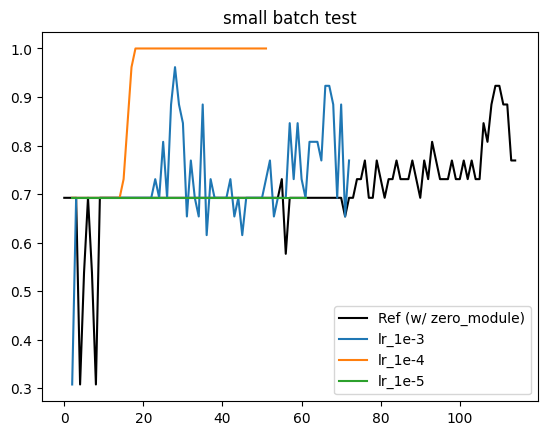

In [63]:

progress = pd.read_csv(files["ref"])
plt.plot(progress['step'], progress['train_acc@1'], label="Ref (w/ zero_module)", color="black")

for key, file_name in files.items():
    if key == "ref":
        continue
    progress = pd.read_csv(file_name)
    plt.plot(progress['step'][2:], progress['train_acc@1'][2:], label=key)
plt.legend()
plt.title("small batch test")
plt.show();

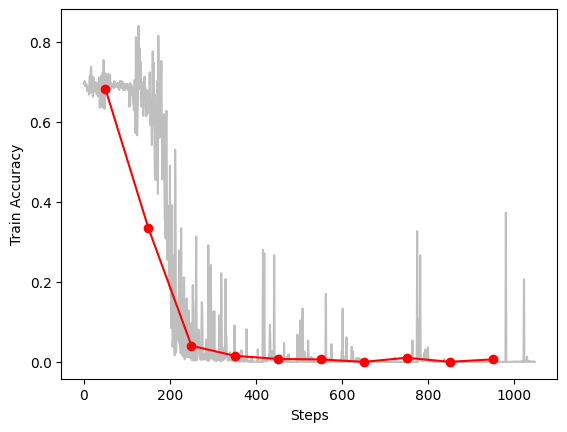

In [ ]:
progress = pd.read_csv("/home/munjung/anomaly-detection/diffusion-anomaly/results/noise_300/progressclassifier_best.csv")

plt.plot(progress['step'], progress['train_loss'], color="gray", alpha=0.5)

epoch_bins = np.arange(0, len(progress), 100)
epoch_centers = (epoch_bins[:-1] + epoch_bins[1:]) / 2
epoch_vals = []
for e in epoch_centers:
    mask = (progress['step'] >= e) & (progress['step'] < e + 100)
    avg_val = progress['train_loss'][mask].mean()
    epoch_vals.append(avg_val)
plt.plot(epoch_centers, epoch_vals, "-o", color="red", )

plt.xlabel("Steps")
plt.ylabel("Train Loss")
plt.legend()
plt.show()

plt.plot(progress['step'], progress['train_acc@1'], color="gray", alpha=0.5)

epoch_bins = np.arange(0, len(progress), 100)
epoch_centers = (epoch_bins[:-1] + epoch_bins[1:]) / 2
epoch_vals = []
for e in epoch_centers:
    mask = (progress['step'] >= e) & (progress['step'] < e + 100)
    avg_val = progress['train_acc@1'][mask].mean()
    epoch_vals.append(avg_val)
plt.plot(epoch_centers, epoch_vals, "-o", color="red", )

plt.xlabel("Steps")
plt.ylabel("Train Accuracy")
plt.show()

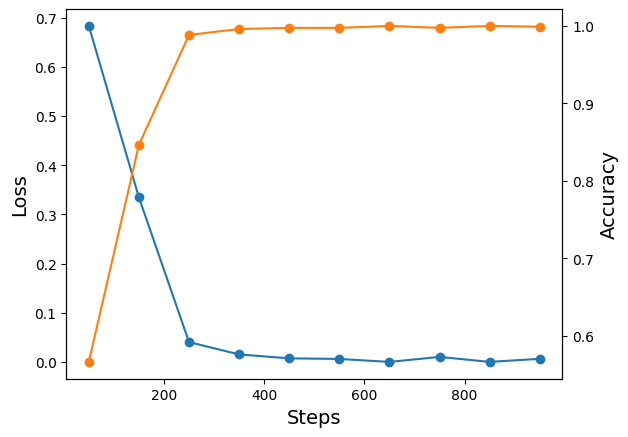

In [75]:
progress = pd.read_csv("/home/munjung/anomaly-detection/diffusion-anomaly/results/noise_300/progressclassifier_best.csv")

fig, ax = plt.subplots()

# plt.plot(progress['step'], progress['train_loss'], color="gray", alpha=0.5)

epoch_bins = np.arange(0, len(progress), 100)
epoch_centers = (epoch_bins[:-1] + epoch_bins[1:]) / 2
epoch_vals = []
for e in epoch_centers:
    mask = (progress['step'] >= e) & (progress['step'] < e + 100)
    avg_val = progress['train_loss'][mask].mean()
    epoch_vals.append(avg_val)
ax.plot(epoch_centers, epoch_vals, "-o", label="Validation loss", color="C0")

# plt.plot(progress['step'], progress['train_acc@1'], color="gray", alpha=0.5)

ax_l = ax.twinx()
epoch_bins = np.arange(0, len(progress), 100)
epoch_centers = (epoch_bins[:-1] + epoch_bins[1:]) / 2
epoch_vals = []
for e in epoch_centers:
    mask = (progress['step'] >= e) & (progress['step'] < e + 100)
    avg_val = progress['train_acc@1'][mask].mean()
    epoch_vals.append(avg_val)
ax_l.plot(epoch_centers, epoch_vals, "-o", label="Validation accuracy", color="C1")

ax.set_ylabel("Loss", fontsize=14)
ax_l.set_ylabel("Accuracy", fontsize=14)
ax.set_xlabel("Steps", fontsize=14)
# plt.ylabel("Train Accuracy")
plt.show()

In [ ]:
# The zero_module helper intentionally sets the weights and bias of that convolution to zero. 
# It is designed so that at initialization, the ResBlock is a perfect identity function. 
# While this is great for diffusion, it can make a standalone classifier extremely slow to 
# start learning because the gradient has to "break" the zero-initialization.

In [ ]:
sample, x_noisy, org = sample_fn(
            model_fn,
            (args["batch_size"], 1, args["image_size"], args["image_size"]), np.array([[img]]), org=np.array([[img]]),
            clip_denoised=True,
            model_kwargs=model_kwargs,
            cond_fn=False,
            device="cuda",
            noise_level=500
        )

In [ ]:
def get_saliency(img, org):
    # img = img.cpu().numpy()
    org = org.cpu().numpy()
    saliency = np.abs(img - org)
    return saliency

In [ ]:
sample = np.array([[origimg]])
noisy = x_noisy[0][0].cpu().numpy()

In [ ]:
saliency = get_saliency(sample[0][0], org[0][0])

fig, axs = plt.subplots(1, 2)
axs[0].imshow(org[0][0].cpu().numpy())
axs[0].set_title("Image")

axs[1].imshow(saliency+noisy*0.03)
axs[1].set_title("Saliency")

plt.show()


In [ ]:
def validation_plots_return(diffusion, model, basedir, img0, ddpm=True):
    save_data = {}

    genf = diffusion.p_sample_loop_progressive if ddpm else diffusion.ddim_sample_loop_progressive
    i0 = img0.cpu().numpy()
    img0 = img0.to(dist_util.dev())

    idiffs = []
    ts = []

    plt.imshow(np.squeeze(i0), vmin=-1, vmax=1)
    plt.colorbar()
    plt.savefig(basedir + "img.png", bbox_inches="tight")
    plt.title("Original Image")
    plt.close()

    save_data["original"] = np.squeeze(i0)

    for i, t in enumerate(range(0, 550, 50)):
        if i == 0: continue

        t = th.tensor(t-1, device=dist_util.dev())
        idiff = diffusion.q_sample(img0, t)
        idiffs.append(idiff)
        ts.append(t)

    for i, (idiff, t) in enumerate(zip(idiffs, ts)):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
        c1 = ax1.imshow(np.squeeze(idiff.cpu().numpy()))
        fig.colorbar(c1, ax=ax1)

        c2 = ax2.imshow(np.squeeze(idiff.cpu().numpy()) - np.squeeze(i0))
        fig.colorbar(c2, ax=ax2)

        plt.title("Diffused T: %i" % int(t))
        plt.savefig(basedir + "diffusion_t%i.png" % int(t), bbox_inches="tight")
        plt.close()

    gens = []
    for (t, idiff) in zip(ts, idiffs):
        gen = genf(model, i0.shape, time=t.item(), noise=idiff.unsqueeze(0))
        final = None
        for g in gen:
            final = g
        gens.append(final)

    for i, (idiff, g, t) in enumerate(zip(idiffs, gens, ts)):
        fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16,4))
        c1 = ax1.imshow(np.squeeze(idiff.cpu().numpy()), vmin=-1, vmax=1)
        fig.colorbar(c1, ax=ax1)
        ax1.title.set_text("Diffused")
    
        c2 = ax2.imshow(np.squeeze(g["sample"].cpu().numpy()), vmin=-1, vmax=1)
        fig.colorbar(c2, ax=ax2)
        ax2.title.set_text("Reconstructed")

        c3 = ax3.imshow(np.squeeze(g["sample"].cpu().numpy()) - np.squeeze(i0))
        fig.colorbar(c3, ax=ax3)
        ax3.title.set_text("Reconstructed - Original")
    
        c4 = ax4.imshow(np.squeeze(g["sample"].cpu().numpy()) - np.squeeze(idiff.cpu().numpy()))
        fig.colorbar(c4, ax=ax4)
        ax4.title.set_text("Reconstructed - Diffused")
        plt.savefig(basedir + "reconstructed_t%i.png" % int(t), bbox_inches="tight")
        plt.close()

        save_data[i] = {
            "diffused": idiff.cpu().numpy(),
            "reconstructed": g["sample"].cpu().numpy(),
            "t": t
        }

    for tind in range(0, i0.shape[1], 50):
        for t, g in list(zip(ts, gens))[::2]:
            lbl = "DDPM" if ddpm else "DDIM"
            plt.plot(np.squeeze(g["sample"].cpu().numpy())[:, tind], label=f"{lbl}, T={t}")
        plt.plot(np.squeeze(i0)[:, tind], label="Original", linewidth=3, color="black", linestyle="--")
        plt.legend()

        plt.title("Reconstructed Waveform, I: %i" % tind)
        plt.savefig(basedir + "reco_wavf_I%i.png" % tind, bbox_inches="tight")
        plt.close()

    plt.plot(np.abs(np.fft.rfft(np.squeeze(i0), axis=0)).sum(axis=1)[1:], label="Original")
    for t, g in list(zip(ts, gens))[::2]:
        plt.plot(np.abs(np.fft.rfft(np.squeeze(g["pred_xstart"].cpu().numpy()), axis=0)).sum(axis=1)[1:], label=f"DDIM, T={t}")

    plt.legend()
    plt.title("Time-Direction Noise Spectrum")
    plt.savefig(basedir + "time_ffts.png", bbox_inches="tight")
    plt.close()

    plt.plot(np.abs(np.fft.rfft(np.squeeze(i0), axis=1)).sum(axis=0)[1:], label="Original")
    for t, g in list(zip(ts, gens))[::2]:
        plt.plot(np.abs(np.fft.rfft(np.squeeze(g["pred_xstart"].cpu().numpy()), axis=1)).sum(axis=0)[1:], label=f"DDIM, T={t}")

    plt.legend()
    plt.title("Wire-Direction Noise Spectrum")
    plt.savefig(basedir + "wire_ffts.png", bbox_inches="tight")
    plt.close()

    loop = list(genf(model, i0.shape, time=ts[-1].item(), noise=idiffs[-1].unsqueeze(0)))

    for i, img in enumerate(loop[49::50]):
        plt.figure()
        plt.imshow(np.squeeze(img["sample"].cpu().numpy()), vmin=-1, vmax=1)
        plt.colorbar()
        plt.title("Reconstruction Series, Step: %i" % (i*50+49))
        plt.savefig(basedir + "reco_img_t%i_to_%i.png" % (int(ts[-1]), i*50+49), bbox_inches="tight")
        plt.close()

    for tind in range(0, i0.shape[1], 50):
        arr = [np.squeeze(img["sample"].cpu().numpy())[:, tind] for img in loop]
        arr = np.array(arr)
        plt.imshow(arr.T, vmin=-1, vmax=1)
        plt.colorbar()
        plt.title("Reconstruction Series, I: %i" % (tind))
        plt.savefig(basedir + "reco_loop_I%i.png" % tind, bbox_inches="tight")
        plt.close()

    return save_data